# Lista de Exercícios — Redes de Camada Única (Perceptron)

**Referência:** Pedro H. A. Konzen, *Deep Learning para Equações Diferenciais Parciais*, Capítulo 2.

- Unidade 2.1: [Unidade de processamento](https://notaspedrok.com.br/deep_learning_para_edps/cap_perceptron_sec_unit.html)
- Unidade 2.2: [Treinamento por retro-propagação](https://notaspedrok.com.br/deep_learning_para_edps/cap_percepton_sec_retroprop.html)

**Conteúdo deste notebook:**

| Seção | Exercício | Descrição |
|-------|-----------|-----------|
| 1 | E. 2.1.1 | Perceptron para OU-lógico (∨) — análise geométrica + algoritmo perceptron |
| 2 | E. 2.1.2 | Tentativa de perceptron para XOR — discussão da impossibilidade |
| 3 | E. 2.1.5 | Regressão com perceptron de ativação tanh |
| 4 | E. 2.2.2 | Perceptron para E-lógico (∧) com GD e SGD |
| 5 | E. 2.2.3 | Perceptron para OU-lógico (∨) com GD e SGD |
| 6 | E. 2.2.4 | Regressão linear com perceptron, treinada com GD e SGD |

> **Convenção de codificação para os booleanos:** V → +1, F → −1.


## Configuração inicial

In [ ]:
# Bibliotecas usadas em todo o notebook
import torch
import matplotlib.pyplot as plt

# Reprodutibilidade
torch.manual_seed(0)

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu130


---
## 1. Exercício 2.1.1 — Perceptron para o OU-lógico (∨)

**Tabela verdade:**

| $A_1$ | $A_2$ | $A_1 \vee A_2$ |
|:---:|:---:|:---:|
| V | V | V |
| V | F | V |
| F | V | V |
| F | F | F |

**Modelo:** perceptron clássico com função de ativação sinal,
$$y = \mathrm{sign}(w_0 x_0 + w_1 x_1 + b).$$

A reta $w_0 x_0 + w_1 x_1 + b = 0$ separa o plano em dois semiplanos. Queremos uma reta que deixe **apenas** o ponto $(-1,-1)$ no semiplano negativo.


### 1.1 Definição do modelo

In [2]:
class Perceptron(torch.nn.Module):
    # Perceptron de 2 entradas com ativação sinal.
    def __init__(self):
        super().__init__()
        # camada linear: 2 entradas -> 1 saída (já inclui o bias)
        self.linear = torch.nn.Linear(2, 1)

    def forward(self, x):
        z = self.linear(x)        # pré-ativação z = w·x + b
        y = torch.sign(z)         # ativação sinal
        return y

### 1.2 Dados de treinamento (V → +1, F → −1)

In [3]:
X_train = torch.tensor([[ 1.,  1.],   # V ∨ V = V
                        [ 1., -1.],   # V ∨ F = V
                        [-1.,  1.],   # F ∨ V = V
                        [-1., -1.]])  # F ∨ F = F
y_train = torch.tensor([1., 1., 1., -1.]).reshape(-1, 1)
ns = y_train.size(0)

print("X_train =\n", X_train)
print("y_train =\n", y_train.flatten())

X_train =
 tensor([[ 1.,  1.],
        [ 1., -1.],
        [-1.,  1.],
        [-1., -1.]])
y_train =
 tensor([ 1.,  1.,  1., -1.])


### 1.3 Parte (a) — Análise geométrica

Tomemos $\mathbf{w} = (1, 1)$ e $b = 1$. Conferindo manualmente:

| $(x_0,x_1)$ | $w_0 x_0 + w_1 x_1 + b$ | sign | esperado |
|:---:|:---:|:---:|:---:|
| $(1,1)$  | $1+1+1=3$  | $+1$ | $+1$ ✓ |
| $(1,-1)$ | $1-1+1=1$  | $+1$ | $+1$ ✓ |
| $(-1,1)$ | $-1+1+1=1$ | $+1$ | $+1$ ✓ |
| $(-1,-1)$| $-1-1+1=-1$| $-1$ | $-1$ ✓ |


In [4]:
model_geo = Perceptron()
with torch.no_grad():
    model_geo.linear.weight = torch.nn.Parameter(torch.tensor([[1., 1.]]))
    model_geo.linear.bias   = torch.nn.Parameter(torch.tensor([1.]))

print("Saídas previstas (escolha geométrica):")
print(model_geo(X_train).detach().numpy().flatten())
print("Esperado:")
print(y_train.numpy().flatten())

Saídas previstas (escolha geométrica):
[ 1.  1.  1. -1.]
Esperado:
[ 1.  1.  1. -1.]


### 1.4 Parte (b) — Algoritmo de treinamento perceptron

**Pseudocódigo (Konzen 2.1.2):**

1. $\mathbf{w}\leftarrow \mathbf{0}$, $b \leftarrow 0$.
2. Para cada época:
   - Para cada amostra $s$:
     - se $y^{(s)} \mathcal N(\mathbf{x}^{(s)}) \le 0$:
       - $\mathbf{w} \leftarrow \mathbf{w} + y^{(s)} \mathbf{x}^{(s)}$
       - $b \leftarrow b + y^{(s)}$
3. Parar quando uma época inteira não fizer correções.


In [5]:
model = Perceptron()
with torch.no_grad():
    model.linear.weight.zero_()   # inicia em zero conforme o algoritmo
    model.linear.bias.zero_()

W = model.linear.weight   # alias (compartilha memória)
b = model.linear.bias

nepochs = 100
for epoch in range(nepochs):
    not_updated = True
    for s in range(ns):
        y_est = model(X_train[s:s+1, :])
        # se errou (ou ficou em cima da fronteira), corrige
        if (y_est * y_train[s] <= 0.):
            with torch.no_grad():
                W += y_train[s] * X_train[s, :]
                b += y_train[s]
                not_updated = False
    if not_updated:
        print(f"Treinamento encerrado na época {epoch}.")
        break

print(f"\nW = {W.detach().numpy()}")
print(f"b = {b.detach().numpy()}")
print(f"Saídas: {model(X_train).detach().numpy().flatten()}")
print(f"Esperado: {y_train.numpy().flatten()}")

Treinamento encerrado na época 1.

W = [[1. 1.]]
b = [1.]
Saídas: [ 1.  1.  1. -1.]
Esperado: [ 1.  1.  1. -1.]


### 1.5 Visualização da reta de separação

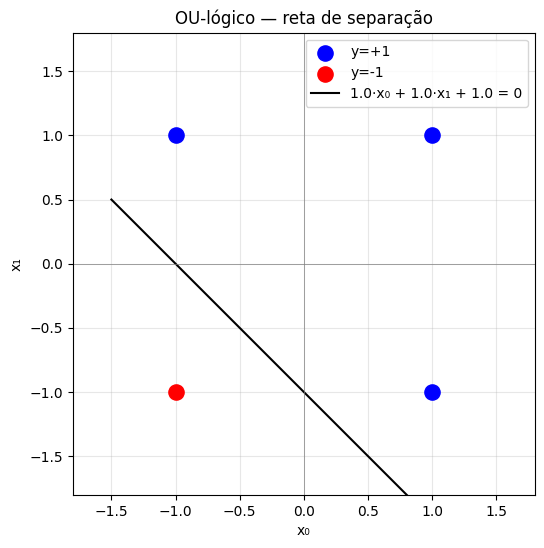

In [6]:
# Pega os parâmetros aprendidos
w0, w1 = W.detach().numpy().flatten()
bb = b.detach().item()

# Reta: w0*x + w1*y + b = 0  ⇒  y = -(w0*x + b)/w1
xx = torch.linspace(-1.5, 1.5, 100).numpy()
yy = -(w0*xx + bb) / w1

plt.figure(figsize=(6, 6))
# Pontos de saída +1 em azul, saída -1 em vermelho
plt.scatter(X_train[y_train.flatten()==1, 0],  X_train[y_train.flatten()==1, 1],
            c='blue', s=120, label='y=+1', zorder=3)
plt.scatter(X_train[y_train.flatten()==-1, 0], X_train[y_train.flatten()==-1, 1],
            c='red',  s=120, label='y=-1', zorder=3)
plt.plot(xx, yy, 'k-', label=f'{w0:.1f}·x₀ + {w1:.1f}·x₁ + {bb:.1f} = 0')
plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
plt.xlim(-1.8, 1.8); plt.ylim(-1.8, 1.8)
plt.gca().set_aspect('equal')
plt.xlabel('x₀'); plt.ylabel('x₁'); plt.title('OU-lógico — reta de separação')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---
## 2. Exercício 2.1.2 — Tentativa de perceptron para o XOR

**Tabela verdade:**

| $A_1$ | $A_2$ | $A_1 \oplus A_2$ |
|:---:|:---:|:---:|
| V | V | F |
| V | F | V |
| F | V | V |
| F | F | F |

**Pergunta:** É possível? **Resposta: não.**

**Justificativa:** Um perceptron de camada única é um *classificador linear* — sua fronteira de decisão é uma reta. Em $(x_0, x_1)$:

- saída $+1$ nos pontos $(1,-1)$ e $(-1,1)$ (uma diagonal);
- saída $-1$ nos pontos $(1,1)$ e $(-1,-1)$ (a outra diagonal).

Os dois conjuntos se cruzam — não há reta que os separe.

**Argumento algébrico:** se existissem $w_0, w_1, b$ resolvendo

$$
\begin{cases}
 w_0 + w_1 + b < 0 & (V,V \to F)\\
 w_0 - w_1 + b > 0 & (V,F \to V)\\
-w_0 + w_1 + b > 0 & (F,V \to V)\\
-w_0 - w_1 + b < 0 & (F,F \to F)
\end{cases}
$$

somando a 1ª e 4ª: $2b < 0 \Rightarrow b < 0$; somando a 2ª e 3ª: $2b > 0 \Rightarrow b > 0$. Contradição. ∎

Vamos mostrar **empiricamente** que o algoritmo de treinamento perceptron não converge para este caso — fica corrigindo pesos para sempre.


In [7]:
# Dados do XOR
X_xor = torch.tensor([[ 1.,  1.],
                      [ 1., -1.],
                      [-1.,  1.],
                      [-1., -1.]])
y_xor = torch.tensor([-1., 1., 1., -1.]).reshape(-1, 1)
ns = y_xor.size(0)

model_xor = Perceptron()
with torch.no_grad():
    model_xor.linear.weight.zero_()
    model_xor.linear.bias.zero_()
W = model_xor.linear.weight
b = model_xor.linear.bias

nepochs = 30
historico_erros = []
print(f"{'época':>6} | {'erros na época':>15}")
print("-" * 30)
convergiu = False
for epoch in range(nepochs):
    erros = 0
    for s in range(ns):
        y_est = model_xor(X_xor[s:s+1, :])
        if (y_est * y_xor[s] <= 0.):
            with torch.no_grad():
                W += y_xor[s] * X_xor[s, :]
                b += y_xor[s]
            erros += 1
    historico_erros.append(erros)
    print(f"{epoch:>6} | {erros:>15}")
    if erros == 0:
        convergiu = True
        break

print("-" * 30)
if not convergiu:
    print("Não converge — o XOR não é linearmente separável.")
print("\nSaídas finais:", model_xor(X_xor).detach().numpy().flatten())
print("Esperado:    ", y_xor.numpy().flatten())

 época |  erros na época
------------------------------
     0 |               4
     1 |               4
     2 |               4
     3 |               4
     4 |               4
     5 |               4
     6 |               4
     7 |               4
     8 |               4
     9 |               4
    10 |               4
    11 |               4
    12 |               4
    13 |               4
    14 |               4
    15 |               4
    16 |               4
    17 |               4
    18 |               4
    19 |               4
    20 |               4
    21 |               4
    22 |               4
    23 |               4
    24 |               4
    25 |               4
    26 |               4
    27 |               4
    28 |               4
    29 |               4
------------------------------
Não converge — o XOR não é linearmente separável.

Saídas finais: [0. 0. 0. 0.]
Esperado:     [-1.  1.  1. -1.]


**Observação:** o número de erros oscila e nunca chega a zero — exatamente o comportamento esperado, pois o algoritmo perceptron só converge para conjuntos linearmente separáveis.

---
## 3. Exercício 2.1.5 — Perceptron com $f(x)=\tanh(x)$ para regressão

**Conjunto de dados:**

| $s$ | $x^{(s)}$ | $y^{(s)}$ |
|:--:|:--:|:--:|
| 1 | -1.0 | -0.8 |
| 2 | -0.7 | -0.7 |
| 3 | -0.3 | -0.5 |
| 4 |  0.0 | -0.4 |
| 5 |  0.2 | -0.2 |
| 6 |  0.5 |  0.0 |
| 7 |  1.0 |  0.3 |

**Modelo:** $y = \tanh(w x + b)$.

Como $\tanh$ é diferenciável em todo lugar, podemos usar gradiente descendente (autograd do PyTorch) para minimizar o erro quadrático médio:
$$\varepsilon(w,b) = \frac{1}{n_s}\sum_{s=1}^{n_s} \left( \tilde y^{(s)} - y^{(s)} \right)^2.$$


In [8]:
class PerceptronTanh(torch.nn.Module):
    # Perceptron 1 entrada, 1 saída, ativação tanh.
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)

    def forward(self, x):
        return torch.tanh(self.linear(x))

# Dados
X_train = torch.tensor([[-1.0], [-0.7], [-0.3], [0.0], [0.2], [0.5], [1.0]])
y_train = torch.tensor([[-0.8], [-0.7], [-0.5], [-0.4], [-0.2], [0.0], [0.3]])

# Treinamento
torch.manual_seed(0)
model = PerceptronTanh()
optim   = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = torch.nn.MSELoss()

nepochs, tol = 5000, 1e-5
historico = []
for epoch in range(nepochs):
    y_est = model(X_train)
    loss  = loss_fn(y_est, y_train)
    historico.append(loss.item())
    if loss.item() < tol:
        print(f"Convergiu na época {epoch} (loss={loss.item():.3e})")
        break
    optim.zero_grad()
    loss.backward()
    optim.step()

w = model.linear.weight.item()
b = model.linear.bias.item()
print(f"\nModelo ajustado: y = tanh({w:.4f}·x + {b:.4f})")


Modelo ajustado: y = tanh(0.6992·x + -0.3702)


In [9]:
# Comparação amostra a amostra
with torch.no_grad():
    y_pred = model(X_train)
print("  s |   x   |  y_real | y_pred")
print("----+-------+---------+--------")
for i in range(len(X_train)):
    print(f"  {i+1} | {X_train[i].item():>5.2f} | "
          f"{y_train[i].item():>7.2f} | {y_pred[i].item():>6.3f}")

  s |   x   |  y_real | y_pred
----+-------+---------+--------
  1 | -1.00 |   -0.80 | -0.789
  2 | -0.70 |   -0.70 | -0.696
  3 | -0.30 |   -0.50 | -0.523
  4 |  0.00 |   -0.40 | -0.354
  5 |  0.20 |   -0.20 | -0.226
  6 |  0.50 |    0.00 | -0.021
  7 |  1.00 |    0.30 |  0.318


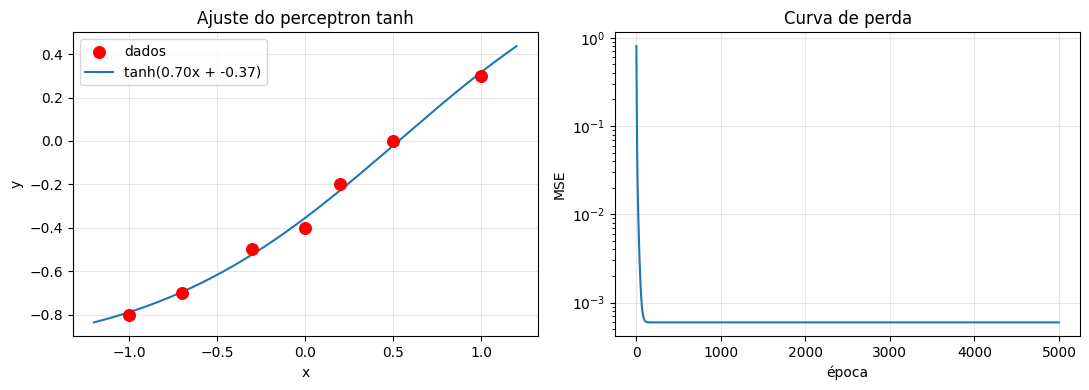

In [10]:
# Visualização: ajuste e curva de perda
xx = torch.linspace(-1.2, 1.2, 200).reshape(-1, 1)
with torch.no_grad():
    yy = model(xx)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].scatter(X_train.numpy(), y_train.numpy(), color='red', s=70, label='dados', zorder=3)
axs[0].plot(xx.numpy(), yy.numpy(), label=f'tanh({w:.2f}x + {b:.2f})')
axs[0].set_xlabel('x'); axs[0].set_ylabel('y')
axs[0].set_title('Ajuste do perceptron tanh')
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].semilogy(historico)
axs[1].set_xlabel('época'); axs[1].set_ylabel('MSE')
axs[1].set_title('Curva de perda'); axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Exercício 2.2.2 — Perceptron para o E-lógico (∧) com GD e SGD

Trocamos a função sinal por $\tanh$ (diferenciável) e treinamos via:

- **(a) GD (Gradient Descent):** atualiza $\mathbf{w}, b$ uma vez por época usando o gradiente do erro médio sobre **todas** as amostras.
- **(b) SGD (Stochastic Gradient Descent):** atualiza $\mathbf{w}, b$ amostra a amostra, embaralhando a ordem a cada época.

**Tabela verdade do E-lógico:**

| $A_1$ | $A_2$ | $A_1 \wedge A_2$ |
|:---:|:---:|:---:|
| V | V | V |
| V | F | F |
| F | V | F |
| F | F | F |


In [11]:
class PerceptronTanh2(torch.nn.Module):
    # Perceptron com 2 entradas, ativação tanh.
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(2, 1)

    def forward(self, x):
        return torch.tanh(self.linear(x))

# Dados do E-lógico
X_and = torch.tensor([[ 1.,  1.],
                      [ 1., -1.],
                      [-1.,  1.],
                      [-1., -1.]])
y_and = torch.tensor([1., -1., -1., -1.]).reshape(-1, 1)
ns = y_and.size(0)

### 4.1 (a) Treinamento com GD

In [12]:
torch.manual_seed(42)
model_gd = PerceptronTanh2()
optim    = torch.optim.SGD(model_gd.parameters(), lr=0.5)
loss_fn  = torch.nn.MSELoss()

nepochs, tol = 2000, 1e-3
hist_gd = []
for epoch in range(nepochs):
    y_est = model_gd(X_and)                  # forward com batch completo
    loss  = loss_fn(y_est, y_and)
    hist_gd.append(loss.item())
    if loss.item() < tol:
        print(f"GD convergiu na época {epoch} (loss={loss.item():.3e})")
        break
    # 1 passo por época, gradiente do batch inteiro
    optim.zero_grad()
    loss.backward()
    optim.step()

print(f"\nW = {model_gd.linear.weight.detach().numpy()}")
print(f"b = {model_gd.linear.bias.detach().numpy()}")
print(f"saídas:   {model_gd(X_and).detach().numpy().flatten()}")
print(f"esperado: {y_and.numpy().flatten()}")

GD convergiu na época 399 (loss=9.992e-04)

W = [[1.9925787 1.9925787]]
b = [-1.9925787]
saídas:   [ 0.9634995 -0.9634995 -0.9634995 -0.9999871]
esperado: [ 1. -1. -1. -1.]


### 4.2 (b) Treinamento com SGD

In [13]:
torch.manual_seed(42)
model_sgd = PerceptronTanh2()
optim     = torch.optim.SGD(model_sgd.parameters(), lr=0.5)
loss_fn   = torch.nn.MSELoss()

nepochs, tol = 2000, 1e-3
hist_sgd = []
for epoch in range(nepochs):
    # avalia loss global apenas para monitorar o critério de parada
    with torch.no_grad():
        loss = loss_fn(model_sgd(X_and), y_and)
    hist_sgd.append(loss.item())
    if loss.item() < tol:
        print(f"SGD convergiu na época {epoch} (loss={loss.item():.3e})")
        break
    # passos amostra a amostra em ordem aleatória
    for s in torch.randperm(ns):
        y_s    = model_sgd(X_and[s:s+1, :])
        loss_s = (y_s - y_and[s:s+1, :])**2
        optim.zero_grad()
        loss_s.backward()
        optim.step()

print(f"\nW = {model_sgd.linear.weight.detach().numpy()}")
print(f"b = {model_sgd.linear.bias.detach().numpy()}")
print(f"saídas:   {model_sgd(X_and).detach().numpy().flatten()}")
print(f"esperado: {y_and.numpy().flatten()}")

SGD convergiu na época 88 (loss=9.960e-04)

W = [[1.9932328 1.9934157]]
b = [-1.9935554]
saídas:   [ 0.9635363  -0.9635825  -0.96355635 -0.99998724]
esperado: [ 1. -1. -1. -1.]


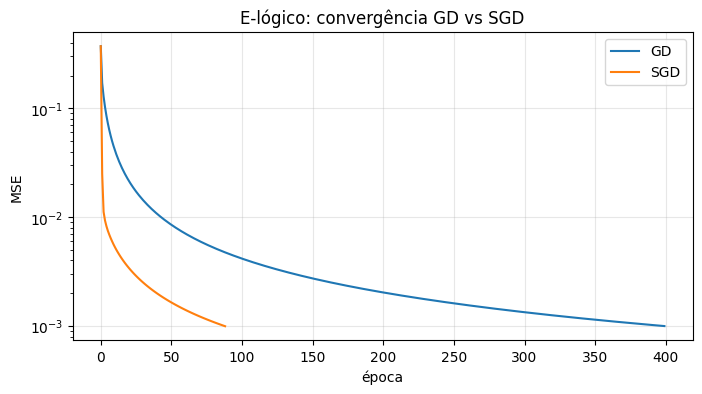

In [14]:
# Comparação das curvas de perda
plt.figure(figsize=(8, 4))
plt.semilogy(hist_gd,  label='GD')
plt.semilogy(hist_sgd, label='SGD')
plt.xlabel('época'); plt.ylabel('MSE')
plt.title('E-lógico: convergência GD vs SGD')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---
## 5. Exercício 2.2.3 — Perceptron para o OU-lógico (∨) com GD e SGD

Mesma estrutura do exercício 4, mas com os dados do OU-lógico.


In [15]:
# Dados do OU-lógico
X_or = torch.tensor([[ 1.,  1.],
                     [ 1., -1.],
                     [-1.,  1.],
                     [-1., -1.]])
y_or = torch.tensor([1., 1., 1., -1.]).reshape(-1, 1)
ns = y_or.size(0)

### 5.1 (a) Treinamento com GD

In [16]:
torch.manual_seed(42)
model_gd = PerceptronTanh2()
optim    = torch.optim.SGD(model_gd.parameters(), lr=0.5)
loss_fn  = torch.nn.MSELoss()

nepochs, tol = 2000, 1e-3
hist_gd = []
for epoch in range(nepochs):
    y_est = model_gd(X_or)
    loss  = loss_fn(y_est, y_or)
    hist_gd.append(loss.item())
    if loss.item() < tol:
        print(f"GD convergiu na época {epoch} (loss={loss.item():.3e})")
        break
    optim.zero_grad()
    loss.backward()
    optim.step()

print(f"\nW = {model_gd.linear.weight.detach().numpy()}")
print(f"b = {model_gd.linear.bias.detach().numpy()}")
print(f"saídas:   {model_gd(X_or).detach().numpy().flatten()}")
print(f"esperado: {y_or.numpy().flatten()}")

GD convergiu na época 400 (loss=9.976e-04)

W = [[1.9930023 1.9930023]]
b = [1.9930023]
saídas:   [ 0.9999872  0.9635298  0.9635298 -0.9635298]
esperado: [ 1.  1.  1. -1.]


### 5.2 (b) Treinamento com SGD

In [17]:
torch.manual_seed(42)
model_sgd = PerceptronTanh2()
optim     = torch.optim.SGD(model_sgd.parameters(), lr=0.5)
loss_fn   = torch.nn.MSELoss()

nepochs, tol = 2000, 1e-3
hist_sgd = []
for epoch in range(nepochs):
    with torch.no_grad():
        loss = loss_fn(model_sgd(X_or), y_or)
    hist_sgd.append(loss.item())
    if loss.item() < tol:
        print(f"SGD convergiu na época {epoch} (loss={loss.item():.3e})")
        break
    for s in torch.randperm(ns):
        y_s    = model_sgd(X_or[s:s+1, :])
        loss_s = (y_s - y_or[s:s+1, :])**2
        optim.zero_grad()
        loss_s.backward()
        optim.step()

print(f"\nW = {model_sgd.linear.weight.detach().numpy()}")
print(f"b = {model_sgd.linear.bias.detach().numpy()}")
print(f"saídas:   {model_sgd(X_or).detach().numpy().flatten()}")
print(f"esperado: {y_or.numpy().flatten()}")

SGD convergiu na época 75 (loss=9.898e-04)

W = [[1.9958395 1.9955536]]
b = [1.9935824]
saídas:   [ 0.99998736  0.9635918   0.9635509  -0.96387255]
esperado: [ 1.  1.  1. -1.]


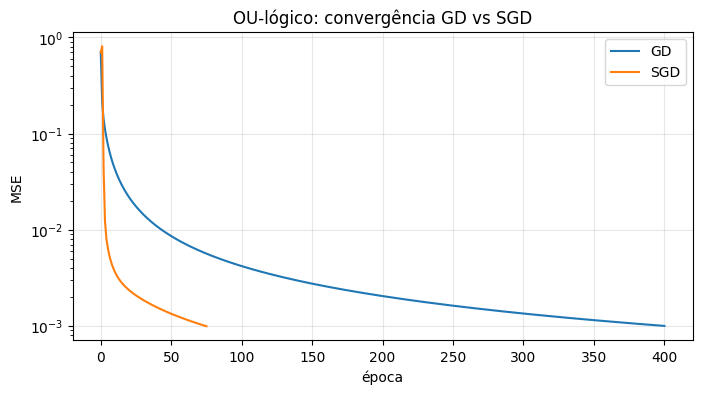

In [18]:
plt.figure(figsize=(8, 4))
plt.semilogy(hist_gd,  label='GD')
plt.semilogy(hist_sgd, label='SGD')
plt.xlabel('época'); plt.ylabel('MSE')
plt.title('OU-lógico: convergência GD vs SGD')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---
## 6. Exercício 2.2.4 — Perceptron para regressão (GD e SGD)

> Observação: o PDF da lista repete o rótulo "2.2.2", mas pelo enunciado é o **E.2.2.4** do site do Prof. Konzen.

**Conjunto de dados:**

| $s$ | $x^{(s)}$ | $y^{(s)}$ |
|:--:|:--:|:--:|
| 1 | 0.5 | 1.2 |
| 2 | 1.0 | 2.1 |
| 3 | 1.5 | 2.6 |
| 4 | 2.0 | 3.6 |

Os dados parecem aproximadamente lineares (o melhor ajuste por mínimos quadrados é $y \approx 1.56\,x + 0.45$).

**Por que ativação identidade e não tanh?** Porque os valores de $y$ chegam a $3.6$, e $\tanh \in (-1,1)$. Para regressão com saídas fora desse intervalo, a ativação precisa ser linear (identidade).

**Modelo:** $y = w x + b$.


In [19]:
class PerceptronLinear(torch.nn.Module):
    # Regressão linear simples como perceptron com ativação identidade.
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)   # sem ativação não-linear

# Dados
X_reg = torch.tensor([[0.5], [1.0], [1.5], [2.0]])
y_reg = torch.tensor([[1.2], [2.1], [2.6], [3.6]])
ns = y_reg.size(0)

### 6.1 (a) Treinamento com GD

In [20]:
torch.manual_seed(0)
model_gd = PerceptronLinear()
optim    = torch.optim.SGD(model_gd.parameters(), lr=0.05)
loss_fn  = torch.nn.MSELoss()

nepochs, tol = 5000, 1e-4
hist_gd = []
for epoch in range(nepochs):
    y_est = model_gd(X_reg)
    loss  = loss_fn(y_est, y_reg)
    hist_gd.append(loss.item())
    if loss.item() < tol:
        print(f"GD convergiu na época {epoch} (loss={loss.item():.3e})")
        break
    optim.zero_grad()
    loss.backward()
    optim.step()

w_gd = model_gd.linear.weight.item()
b_gd = model_gd.linear.bias.item()
print(f"\nModelo GD:  y = {w_gd:.4f}·x + {b_gd:.4f}")


Modelo GD:  y = 1.5400·x + 0.4500


### 6.2 (b) Treinamento com SGD

In [21]:
torch.manual_seed(0)
model_sgd = PerceptronLinear()
optim     = torch.optim.SGD(model_sgd.parameters(), lr=0.05)
loss_fn   = torch.nn.MSELoss()

nepochs, tol = 5000, 1e-4
hist_sgd = []
for epoch in range(nepochs):
    with torch.no_grad():
        loss = loss_fn(model_sgd(X_reg), y_reg)
    hist_sgd.append(loss.item())
    if loss.item() < tol:
        print(f"SGD convergiu na época {epoch} (loss={loss.item():.3e})")
        break
    for s in torch.randperm(ns):
        y_s    = model_sgd(X_reg[s:s+1, :])
        loss_s = (y_s - y_reg[s:s+1, :])**2
        optim.zero_grad()
        loss_s.backward()
        optim.step()

w_sgd = model_sgd.linear.weight.item()
b_sgd = model_sgd.linear.bias.item()
print(f"\nModelo SGD: y = {w_sgd:.4f}·x + {b_sgd:.4f}")


Modelo SGD: y = 1.5312·x + 0.4308


In [22]:
# Tabela comparativa
with torch.no_grad():
    yp_gd  = model_gd(X_reg)
    yp_sgd = model_sgd(X_reg)

print(" s |  x  |  y_real | y_GD   | y_SGD")
print("---+-----+---------+--------+--------")
for i in range(ns):
    print(f" {i+1} | {X_reg[i].item():>3.1f} | {y_reg[i].item():>7.2f} | "
          f"{yp_gd[i].item():>6.3f} | {yp_sgd[i].item():>6.3f}")

 s |  x  |  y_real | y_GD   | y_SGD
---+-----+---------+--------+--------
 1 | 0.5 |    1.20 |  1.220 |  1.196
 2 | 1.0 |    2.10 |  1.990 |  1.962
 3 | 1.5 |    2.60 |  2.760 |  2.728
 4 | 2.0 |    3.60 |  3.530 |  3.493


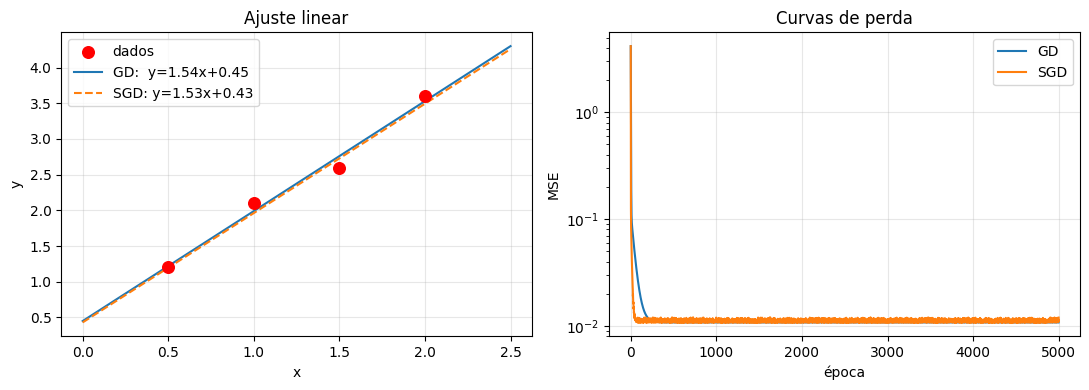

In [23]:
# Visualização: ajuste e curvas de perda
xx = torch.linspace(0, 2.5, 100).reshape(-1, 1)
with torch.no_grad():
    yy_gd  = model_gd(xx)
    yy_sgd = model_sgd(xx)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].scatter(X_reg.numpy(), y_reg.numpy(), color='red', s=70, label='dados', zorder=3)
axs[0].plot(xx.numpy(), yy_gd.numpy(),  label=f'GD:  y={w_gd:.2f}x+{b_gd:.2f}')
axs[0].plot(xx.numpy(), yy_sgd.numpy(), '--',
            label=f'SGD: y={w_sgd:.2f}x+{b_sgd:.2f}')
axs[0].set_xlabel('x'); axs[0].set_ylabel('y')
axs[0].set_title('Ajuste linear'); axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].semilogy(hist_gd,  label='GD')
axs[1].semilogy(hist_sgd, label='SGD')
axs[1].set_xlabel('época'); axs[1].set_ylabel('MSE')
axs[1].set_title('Curvas de perda'); axs[1].legend(); axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Conclusões

1. **Linearmente separáveis** (E-lógico, OU-lógico): tanto a análise geométrica quanto o algoritmo perceptron convergem rapidamente. Trocando a ativação por $\tanh$, GD e SGD também convergem — GD costuma ter trajetória mais suave, SGD apresenta oscilações mas pode escapar de regiões ruins mais facilmente.

2. **Não linearmente separável** (XOR): o perceptron de camada única é incapaz, e isso pode ser visto tanto algebricamente quanto rodando o algoritmo (que oscila indefinidamente). A solução é usar mais de uma camada (perceptron multicamadas — capítulo 3 do Konzen).

3. **Regressão**: o mesmo arcabouço serve, trocando a ativação para algo apropriado à faixa da saída ($\tanh$ se $y \in (-1,1)$, identidade caso contrário) e usando MSE como função de perda.
